# 01 - EDA, Dataset and Tokenizer

Obiettivo: capire il dataset Rotten Tomatoes e il formato di input richiesto da DistilBERT prima di costruire la baseline.


## 1. Setup

Importiamo le librerie e i moduli locali. Il notebook e' pensato per girare su Windows, macOS o CPU: `get_device` rileva automaticamente `cuda`, poi `mps` (Mac Apple Silicon), infine `cpu`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(str(Path("..").resolve()))

from src.data import LABEL_NAMES, load_rotten_tomatoes
from src.features import load_distilbert_components
from src.utils import get_device, set_seed

set_seed(42)
device = get_device()
print(f"Device selezionato: {device}")


Device selezionato: mps


### Osservazioni

- Questa cella stabilisce l'ambiente di lavoro e rende esplicito il device usato.
- `cuda` (GPU NVIDIA su Windows/Linux) o `mps` (Mac Apple Silicon, come in questa run) accelerano il passaggio nel modello rispetto alla CPU.
- La riproducibilita' e' importante per confrontare in modo corretto baseline e fine-tuning.

## 2. Caricamento del dataset

Carichiamo Rotten Tomatoes tramite Hugging Face Datasets e controlliamo gli split disponibili.


In [2]:
dataset_dict = load_rotten_tomatoes()
dataset_dict


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 8530
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
})

In [3]:
for split, dataset in dataset_dict.items():
    print(f"{split}: {len(dataset)} esempi")
    print(dataset.features)
    print()


train: 8530 esempi
{'text': Value(dtype='string', id=None), 'label': ClassLabel(names=['neg', 'pos'], id=None)}

validation: 1066 esempi
{'text': Value(dtype='string', id=None), 'label': ClassLabel(names=['neg', 'pos'], id=None)}

test: 1066 esempi
{'text': Value(dtype='string', id=None), 'label': ClassLabel(names=['neg', 'pos'], id=None)}



### Osservazioni

- Il dataset e' gia' diviso in tre split: `train` con 8530 esempi, `validation` con 1066 esempi e `test` con 1066 esempi.
- Ogni esempio contiene due campi: `text`, cioe' la frase della recensione, e `label`, cioe' la classe di sentiment.
- Le label sono binarie: `0` per sentiment negativo e `1` per sentiment positivo. Questa struttura conferma che il problema e' una classificazione binaria di testo.


## 3. Ispezione degli esempi

Visualizziamo alcuni esempi per capire che tipo di testi deve classificare il modello.


In [4]:
train_ds = dataset_dict["train"]

for index in range(5):
    row = train_ds[index]
    label_name = LABEL_NAMES[row["label"]]
    print(f"[{index}] {label_name}: {row['text']}")


[0] positive: the rock is destined to be the 21st century's new " conan " and that he's going to make a splash even greater than arnold schwarzenegger , jean-claud van damme or steven segal .
[1] positive: the gorgeously elaborate continuation of " the lord of the rings " trilogy is so huge that a column of words cannot adequately describe co-writer/director peter jackson's expanded vision of j . r . r . tolkien's middle-earth .
[2] positive: effective but too-tepid biopic
[3] positive: if you sometimes like to go to the movies to have fun , wasabi is a good place to start .
[4] positive: emerges as something rare , an issue movie that's so honest and keenly observed that it doesn't feel like one .


In [5]:
rng = np.random.default_rng(42)
sample_indices = rng.choice(len(train_ds), size=10, replace=False)

for index in sample_indices:
    row = train_ds[int(index)]
    label_name = LABEL_NAMES[row["label"]]
    print(f"{label_name}: {row['text']}")


positive: the hours makes you examine your own life in much the same way its characters do , and the experience is profound . the hours is what movies are supposed to be . . .
negative: divertingly ridiculous , headbangingly noisy .
positive: andersson creates a world that's at once surreal and disturbingly familiar ; absurd , yet tremendously sad .
negative: a bland animated sequel that hardly seems worth the effort .
positive: like all of egoyan's work , ararat is fiercely intelligent and uncommonly ambitious .
positive: this enthralling documentary . . . is at once playful and haunting , an in-depth portrait of an iconoclastic artist who was fundamentally unknowable even to his closest friends .
negative: delivers the same old same old , tarted up with latin flava and turned out by hollywood playas .
positive: a psychological thriller with a smart script and an obsessive-compulsive's attention to detail .
positive: the casting of von sydow . . . is itself intacto's luckiest stroke .

### Osservazioni

- Gli esempi sono frasi brevi tratte da recensioni cinematografiche, non recensioni complete.
- Alcune frasi contengono parole chiaramente valutative, come giudizi positivi o negativi espliciti; altre sono piu' sottili e richiedono di interpretare il contesto.
- Il task non richiede generazione di testo: dato un input testuale, il modello deve assegnare una delle due classi di sentiment.


## 4. Distribuzione delle classi

Controlliamo se le classi positive e negative sono bilanciate nei diversi split.


In [6]:
class_counts = {}
for split, dataset in dataset_dict.items():
    labels = pd.Series(dataset["label"]).map(LABEL_NAMES)
    class_counts[split] = labels.value_counts().sort_index()

class_distribution = pd.DataFrame(class_counts).fillna(0).astype(int)
class_distribution


,train,validation,test
negative,4265,533,533
positive,4265,533,533


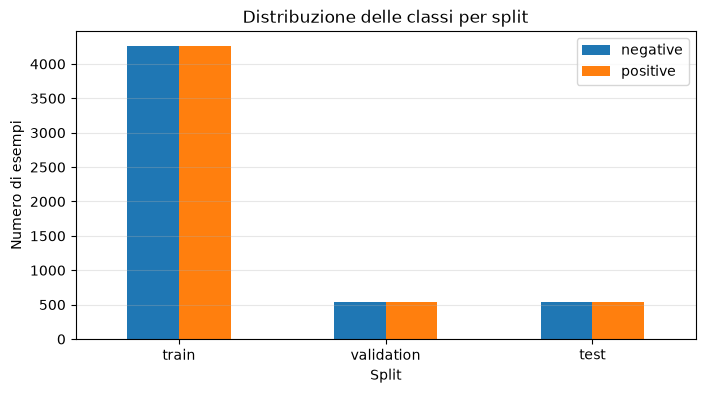

In [7]:
class_distribution.T.plot(kind="bar", figsize=(8, 4))
plt.title("Distribuzione delle classi per split")
plt.xlabel("Split")
plt.ylabel("Numero di esempi")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()


### Osservazioni

- Gli split sono perfettamente bilanciati: nel training set ci sono 4265 esempi negativi e 4265 positivi; validation e test hanno 533 esempi per classe.
- Questo bilanciamento rende l'accuracy una metrica gia' informativa, perche' un modello non puo' ottenere buoni risultati semplicemente preferendo la classe piu' frequente.
- Useremo comunque anche F1 macro e classification report, per controllare che le prestazioni siano simili su entrambe le classi.


## 5. Lunghezza dei testi

Analizziamo la lunghezza delle frasi in parole. Questa informazione aiuta a scegliere `max_length` per tokenizer e modello.


In [8]:
length_stats = {}
for split, dataset in dataset_dict.items():
    lengths = pd.Series([len(text.split()) for text in dataset["text"]])
    length_stats[split] = lengths.describe(percentiles=[0.5, 0.9, 0.95, 0.99])

pd.DataFrame(length_stats)


,train,validation,test
count,8530.000000,1066.000000,1066.000000
mean,20.992849,20.997186,21.220450
std,9.371094,9.639950,9.518807
min,1.000000,1.000000,3.000000
50%,20.000000,21.000000,20.000000
90%,34.000000,34.000000,34.000000
95%,37.000000,38.000000,38.000000
99%,45.000000,46.000000,45.000000
max,59.000000,54.000000,52.000000


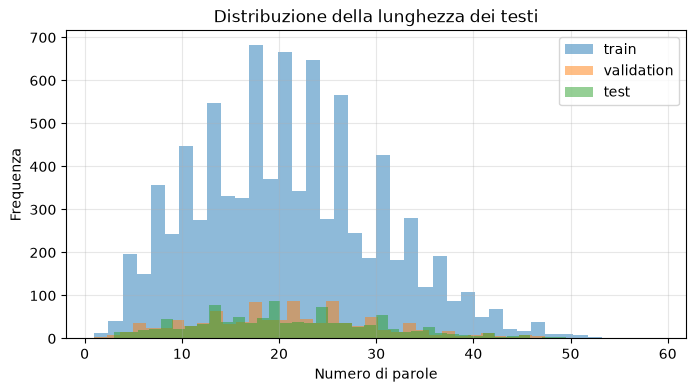

In [9]:
plt.figure(figsize=(8, 4))
for split, dataset in dataset_dict.items():
    lengths = [len(text.split()) for text in dataset["text"]]
    plt.hist(lengths, bins=40, alpha=0.5, label=split)

plt.title("Distribuzione della lunghezza dei testi")
plt.xlabel("Numero di parole")
plt.ylabel("Frequenza")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Osservazioni

- Le frasi sono corte: la mediana e' circa 20-21 parole e il 99% degli esempi resta sotto circa 45-46 parole.
- Questo rende ragionevole usare `max_length=128` token nei passaggi successivi: e' una soglia sufficientemente ampia per il dataset e piu' efficiente di 512.
- Limitare la lunghezza riduce tempo e memoria durante feature extraction e fine-tuning senza tagliare la maggior parte delle frasi.


## 6. Tokenizer DistilBERT

Il tokenizer converte testo in numeri. Questi numeri sono gli input effettivi del modello.


In [10]:
tokenizer, model = load_distilbert_components(device=device)
example_text = train_ds[0]["text"]
encoded = tokenizer(example_text, return_tensors="pt")

print(example_text)
print(encoded)
print(tokenizer.convert_ids_to_tokens(encoded["input_ids"][0]))


the rock is destined to be the 21st century's new " conan " and that he's going to make a splash even greater than arnold schwarzenegger , jean-claud van damme or steven segal .
{'input_ids': tensor([[  101,  1996,  2600,  2003, 16036,  2000,  2022,  1996,  7398,  2301,
          1005,  1055,  2047,  1000, 16608,  1000,  1998,  2008,  2002,  1005,
          1055,  2183,  2000,  2191,  1037, 17624,  2130,  3618,  2084,  7779,
         29058,  8625, 13327,  1010,  3744,  1011, 18856, 19513,  3158,  5477,
          4168,  2030,  7112, 16562,  2140,  1012,   102]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}
['[CLS]', 'the', 'rock', 'is', 'destined', 'to', 'be', 'the', '21st', 'century', "'", 's', 'new', '"', 'conan', '"', 'and', 'that', 'he', "'", 's', 'going', 'to', 'make', 'a', 'splash', 'even', 'greater', 'than', 'arnold', 'schwarz', '##ene', '##gger'

### Osservazioni

- Il tokenizer spezza il testo in token WordPiece: alcune parole rare vengono divise in sottoparti, ad esempio con prefisso `##`.
- `input_ids` contiene gli identificativi numerici dei token, mentre `attention_mask` indica quali posizioni corrispondono a token reali.
- I token speciali `[CLS]` e `[SEP]` delimitano la sequenza. In particolare, useremo la rappresentazione del token `[CLS]` come riassunto numerico della frase.


## 7. Output del modello base

Passiamo pochi esempi in DistilBERT per osservare la forma dell'output.


In [11]:
texts = train_ds[:2]["text"]
batch = tokenizer(texts, padding=True, truncation=True, max_length=128, return_tensors="pt")
batch = {key: value.to(device) for key, value in batch.items()}

outputs = model(**batch)
print(outputs.last_hidden_state.shape)
print(outputs.last_hidden_state[:, 0, :].shape)


torch.Size([2, 52, 768])
torch.Size([2, 768])


### Osservazioni

- Su due frasi, `last_hidden_state` ha forma `(2, 52, 768)`: 2 esempi, 52 token dopo padding/troncamento dinamico, 768 dimensioni per ogni token.
- Il vettore `[CLS]` ha forma `(2, 768)`, quindi ogni frase puo' essere rappresentata da un vettore fisso di 768 numeri.
- Questa osservazione giustifica la baseline del prossimo notebook: DistilBERT trasformera' ogni frase in una feature di dimensione 768, poi un classificatore lineare imparera' a distinguere sentiment positivo e negativo.


## 8. Sintesi finale

Il dataset Rotten Tomatoes e' un problema di classificazione binaria bilanciato: ogni frase e' associata a un sentiment negativo o positivo. L'EDA mostra che i testi sono brevi, quindi `max_length=128` e' una scelta pratica e coerente con i dati.

Il tokenizer converte le frasi in tensori (`input_ids` e `attention_mask`) e DistilBERT produce rappresentazioni contestuali di dimensione 768. Nel notebook successivo useremo il vettore `[CLS]` dell'ultimo layer come feature fissa per costruire una baseline con `LinearSVC`.
